# Title: Diabetes Prediction 
`Author:` [Md Mamun Rasid Prodhan](https://www.linkedin.com/in/mamun-rasid-prodhan/)\
`Dataset:` [Pima Indians Diabetes Dataset](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

# Meta Data (About Dataset)
## Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

## Content
The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

## Acknowledgements
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.


## Aims and Objective:

1. Explore the Dataset: Investigate patterns, distributions, and relationships within the data.
2. Conduct Extensive Exploratory Data Analysis (EDA): Dive into bivariate relationships against the target variable.
3. Preprocessing Steps:
    - Remove irrelevant features
   - Address missing values
    - Treat outliers
    - Encode categorical variables
    - Transform skewed features to achieve normal-like distributions
4. Model Building:
    - Build a Machine Learning Model
    - Check the Accuracy of the ML model

## Import Libraries
Let's start the project by importing all the libries that will need.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Load the dataset

In [2]:
df = pd.read_csv("C:\\Users\\HP\\newPython\\data_Science\\ML\\project\\Diabetes Prediction using MachineLearning\\diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# number of rows and column in the dataset
df.shape

(768, 9)

## Exploratory Data Analysis (EDA)¶
### Explore each column

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Statistical measure of the dataset

In [5]:
#Summary statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# check null values in the data 
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# check the duplicate values in the row
df.duplicated().sum()

0

### number of people have diabetes or not

In [8]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

***here `0` is not diabetes and `1` define Diabetes**

In [9]:
print("\n" + "=" * 60)
print("   TARGET VARIABLE ANALYSIS")
print("=" * 60)
counts = df['Outcome'].value_counts()
pcts   = df['Outcome'].value_counts(normalize=True) * 100
print(f"\n  No Diabetes (0): {counts[0]}  ({pcts[0]:.1f}%)")
print(f"  Diabetes    (1): {counts[1]}  ({pcts[1]:.1f}%)")


   TARGET VARIABLE ANALYSIS

  No Diabetes (0): 500  (65.1%)
  Diabetes    (1): 268  (34.9%)


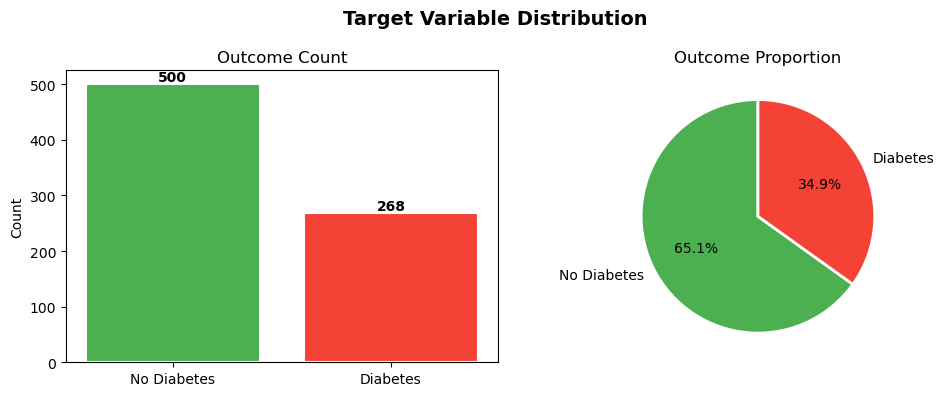

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Target Variable Distribution", fontsize=14, fontweight='bold')

axes[0].bar(['No Diabetes', 'Diabetes'], counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title("Outcome Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Diabetes', 'Diabetes'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Outcome Proportion")

plt.tight_layout()
plt.show()

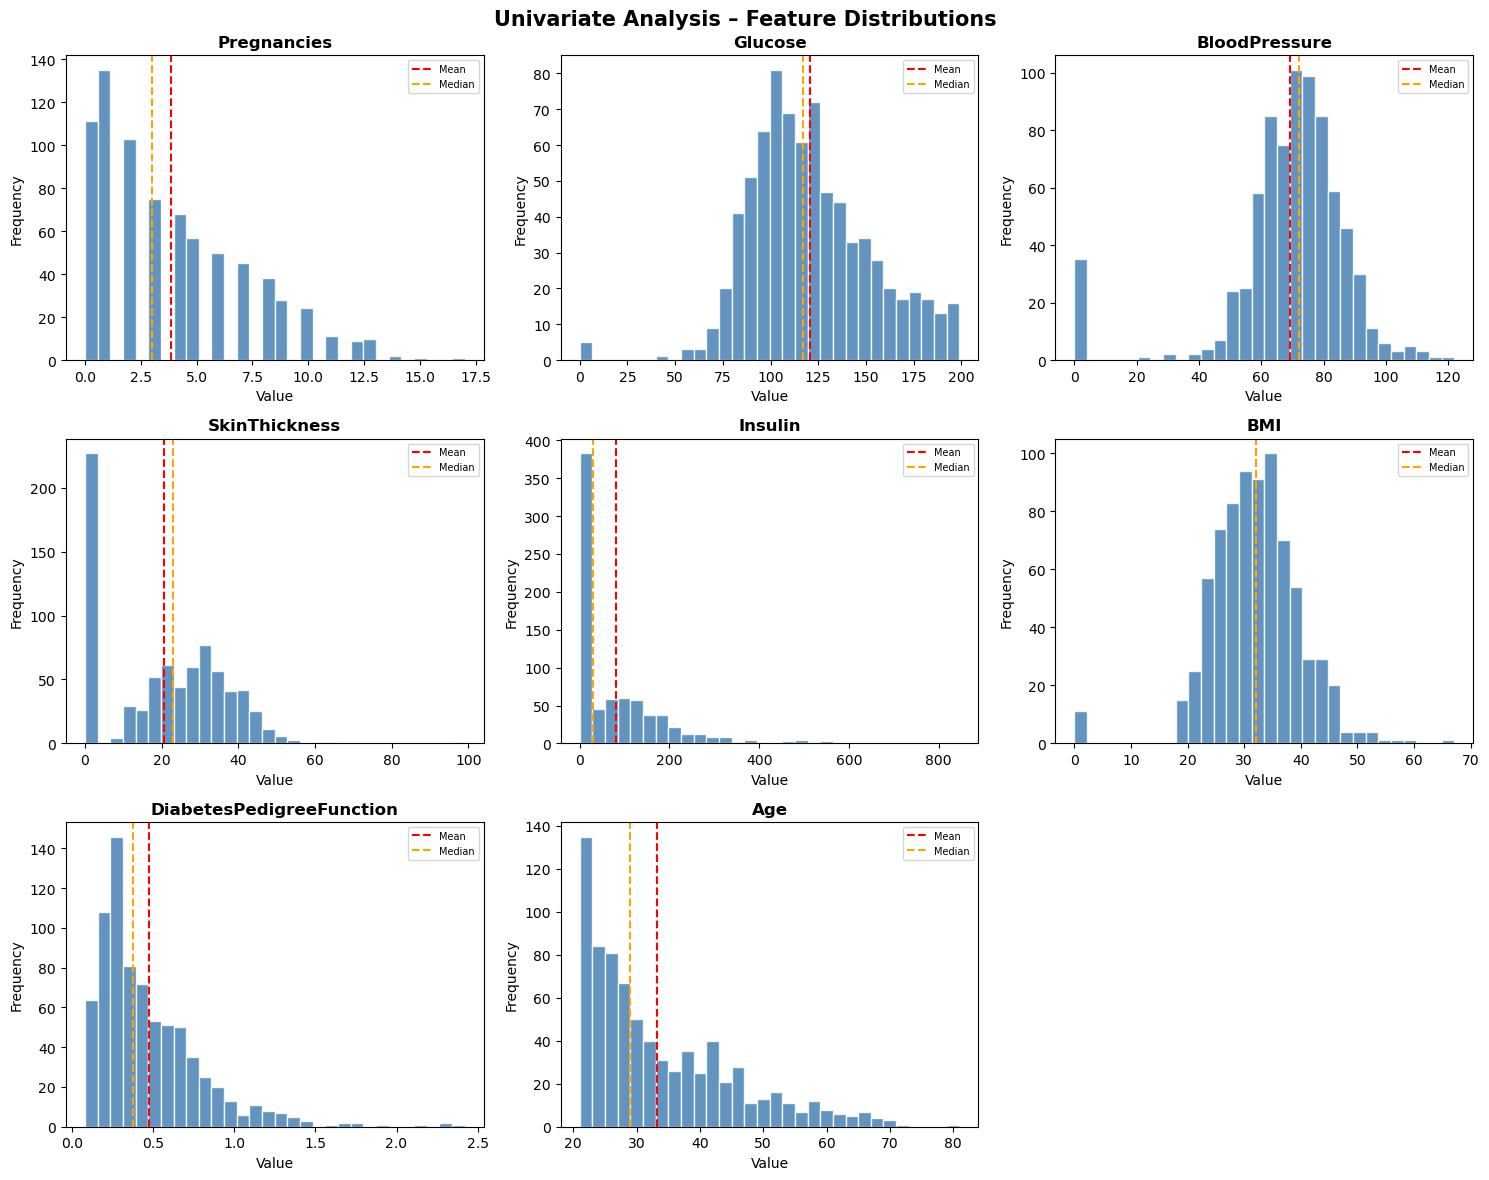

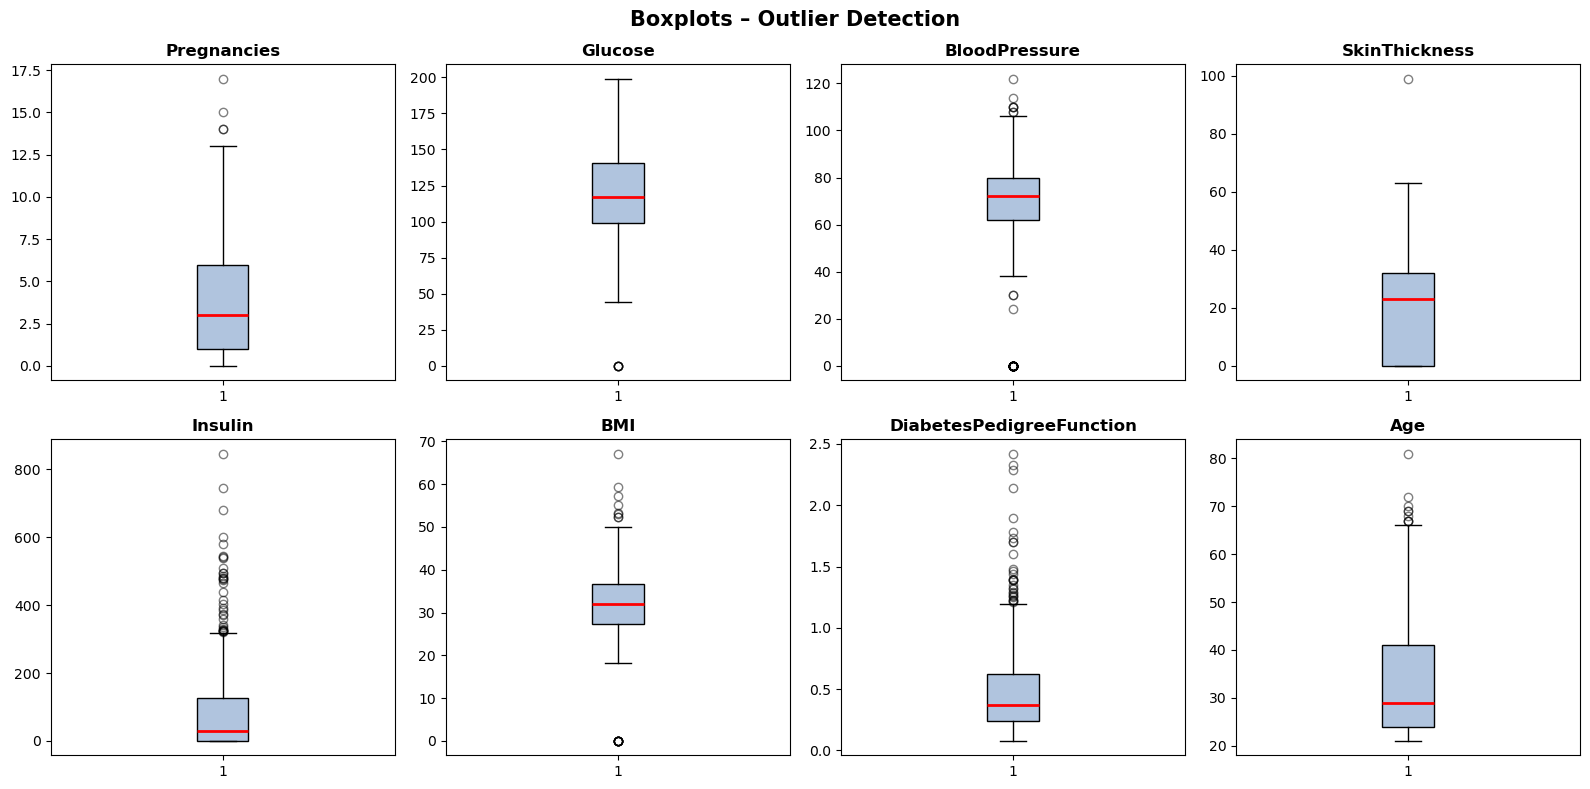


   SKEWNESS & KURTOSIS

Feature                        Skewness   Kurtosis
--------------------------------------------------
  Pregnancies                     0.902      0.159
  Glucose                         0.174      0.641
  BloodPressure                  -1.844      5.180
  SkinThickness                   0.109     -0.520
  Insulin                         2.272      7.214
  BMI                            -0.429      3.290
  DiabetesPedigreeFunction        1.920      5.595
  Age                             1.130      0.643


In [11]:
features = [c for c in df.columns if c != 'Outcome']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Univariate Analysis – Feature Distributions", fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label='Median')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=7)

axes[-1].set_visible(False)   # hide empty 9th subplot
plt.tight_layout()
plt.savefig("plot_02_univariate_histograms.png", bbox_inches='tight')
plt.show()


# Boxplots – outlier detection
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Boxplots – Outlier Detection", fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange', alpha=0.5))
    axes[i].set_title(col, fontweight='bold')

plt.tight_layout()
plt.savefig("plot_03_boxplots.png", bbox_inches='tight')
plt.show()


# Skewness & Kurtosis
print("\n" + "=" * 60)
print("   SKEWNESS & KURTOSIS")
print("=" * 60)
print(f"\n{'Feature':<28} {'Skewness':>10} {'Kurtosis':>10}")
print("-" * 50)
for col in features:
    sk = df[col].skew()
    ku = df[col].kurt()
    print(f"  {col:<26} {sk:>10.3f} {ku:>10.3f}")

### Bivarite Analysis

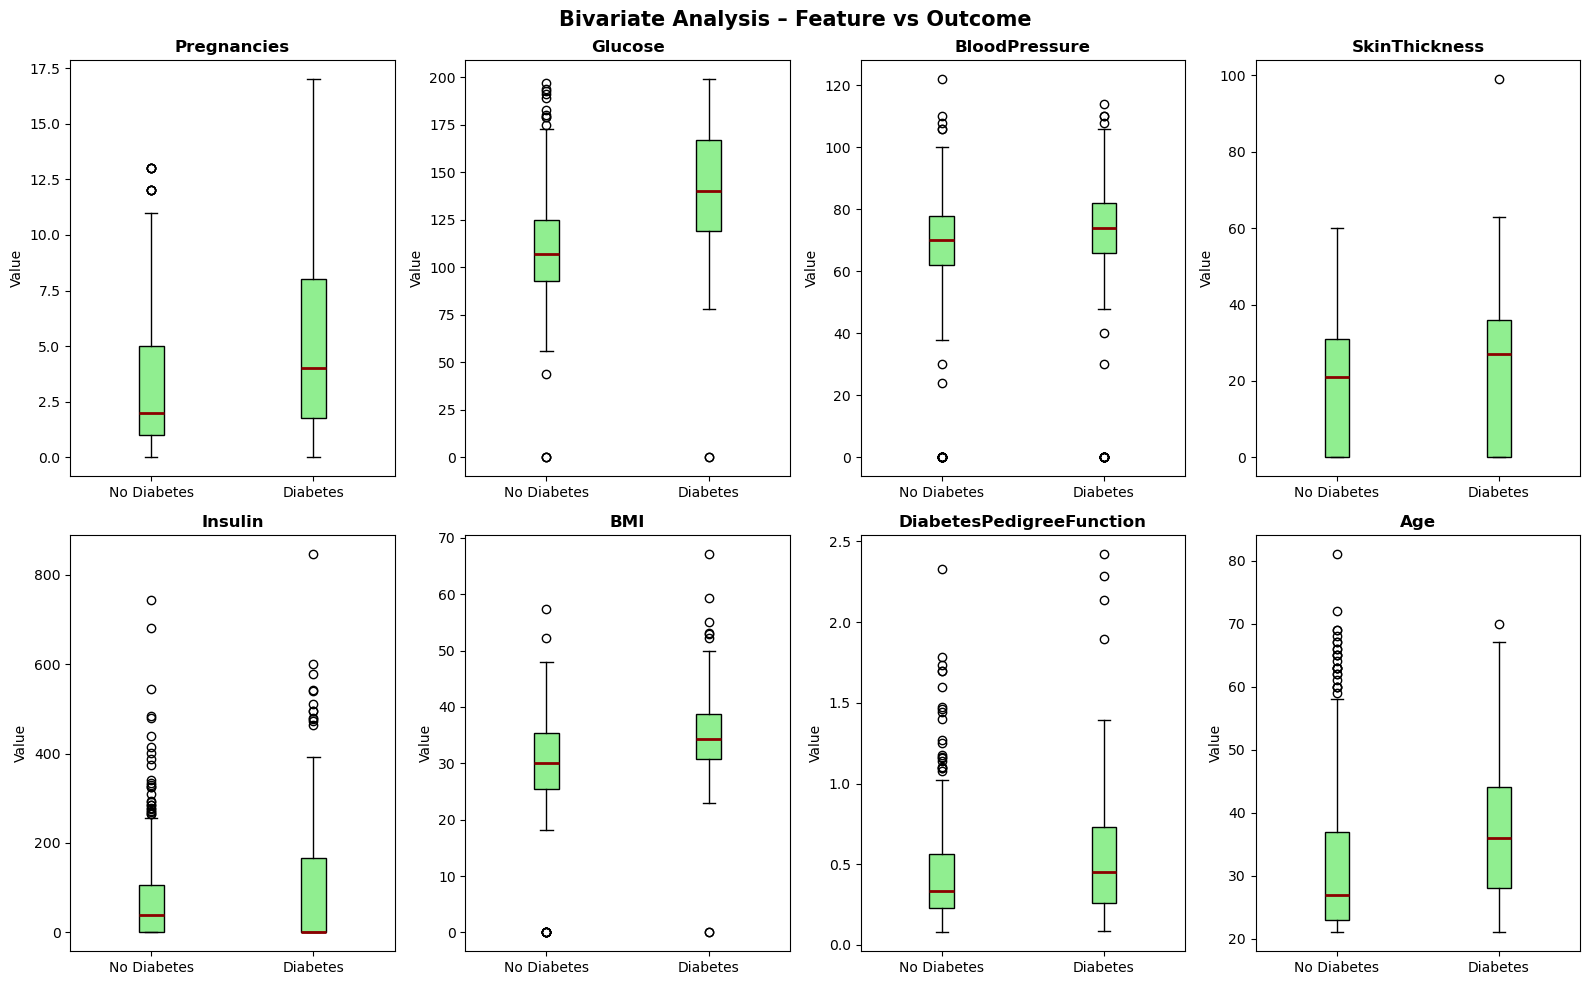

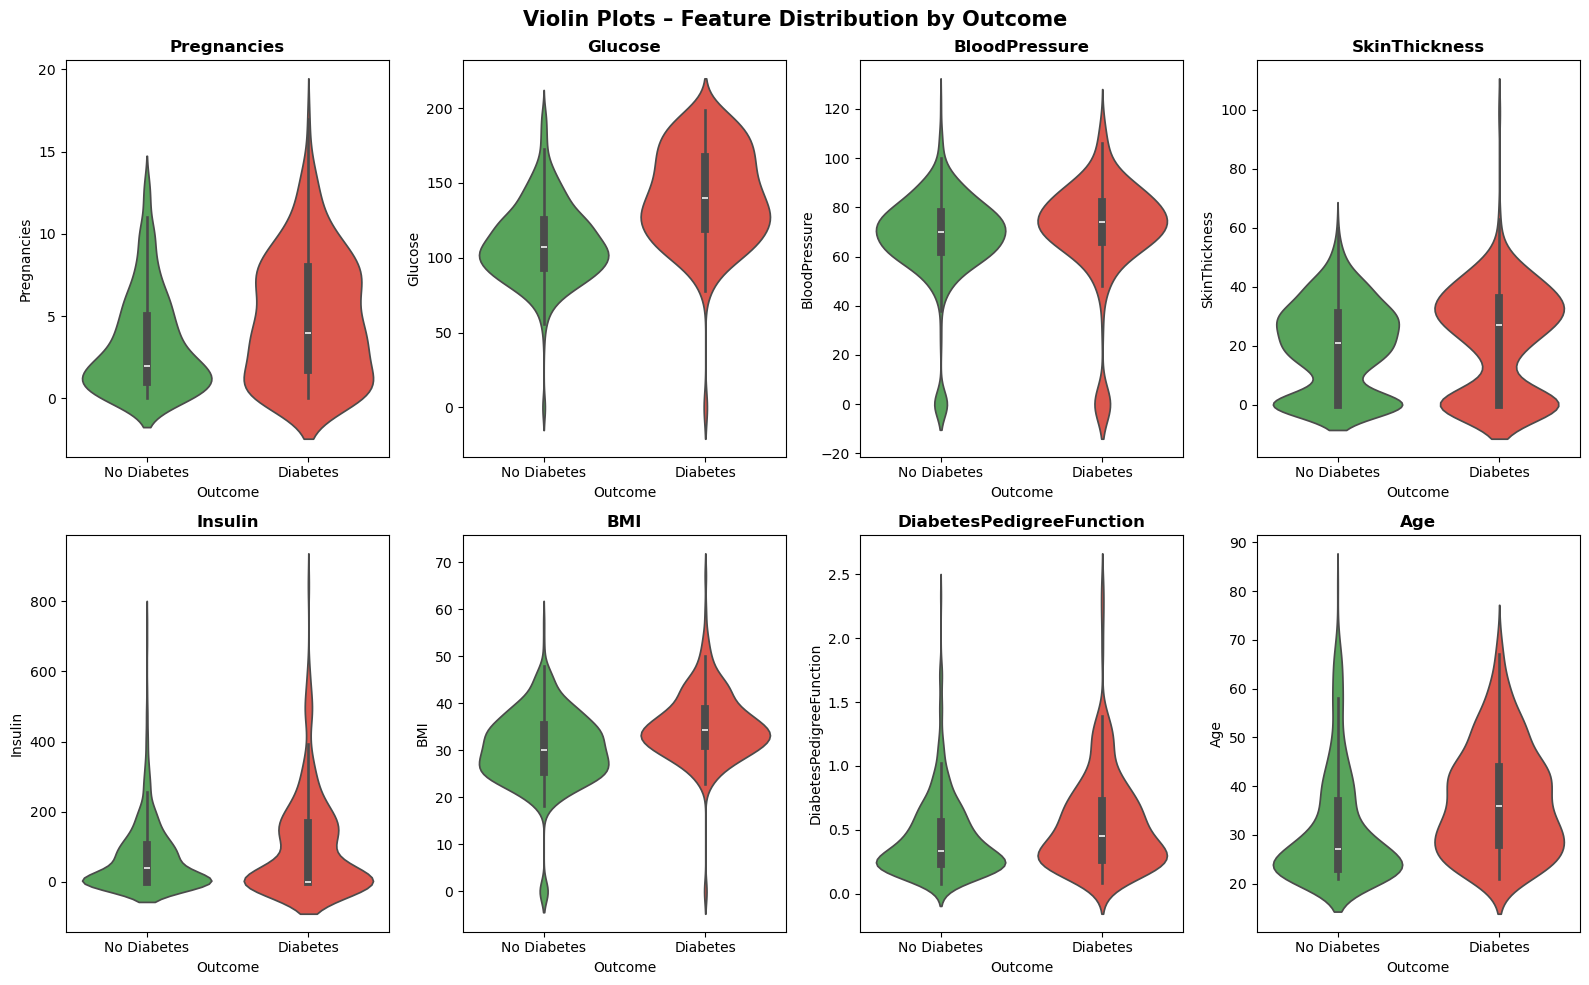


   MEAN COMPARISON BY CLASS (T-Test)

Feature                        Mean(0)   Mean(1)    p-value   Significant?
---------------------------------------------------------------------------
  Pregnancies                     3.30      4.87     0.0000          ✅ YES
  Glucose                       109.98    141.26     0.0000          ✅ YES
  BloodPressure                  68.18     70.82     0.0715           ❌ NO
  SkinThickness                  19.66     22.16     0.0383          ✅ YES
  Insulin                        68.79    100.34     0.0003          ✅ YES
  BMI                            30.30     35.14     0.0000          ✅ YES
  DiabetesPedigreeFunction        0.43      0.55     0.0000          ✅ YES
  Age                            31.19     37.07     0.0000          ✅ YES


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle("Bivariate Analysis – Feature vs Outcome", fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(features):
    data0 = df[df['Outcome'] == 0][col]
    data1 = df[df['Outcome'] == 1][col]
    axes[i].boxplot([data0, data1], labels=['No Diabetes', 'Diabetes'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'),
                    medianprops=dict(color='darkred', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.savefig("plot_04_bivariate_boxplots.png", bbox_inches='tight')
plt.show()


# Violin plots
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle("Violin Plots – Feature Distribution by Outcome", fontsize=15, fontweight='bold')
axes = axes.flatten()

df_str = df.copy(); df_str["Outcome"] = df_str["Outcome"].astype(str)
for i, col in enumerate(features):
    sns.violinplot(x="Outcome", y=col, data=df_str, ax=axes[i],
                   palette={"0": "#4CAF50", "1": "#F44336"},
                   order=["0", "1"])
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xticklabels(["No Diabetes", "Diabetes"])

plt.tight_layout()
plt.savefig("plot_05_violin_plots.png", bbox_inches='tight')
plt.show()


# Mean comparison by class
print("\n" + "=" * 60)
print("   MEAN COMPARISON BY CLASS (T-Test)")
print("=" * 60)
print(f"\n{'Feature':<28} {'Mean(0)':>9} {'Mean(1)':>9} {'p-value':>10} {'Significant?':>14}")
print("-" * 75)
for col in features:
    g0 = df[df['Outcome'] == 0][col]
    g1 = df[df['Outcome'] == 1][col]
    t_stat, p_val = stats.ttest_ind(g0, g1)
    sig = "✅ YES" if p_val < 0.05 else "❌ NO"
    print(f"  {col:<26} {g0.mean():>9.2f} {g1.mean():>9.2f} {p_val:>10.4f} {sig:>14}")


### Multivariate Analysis

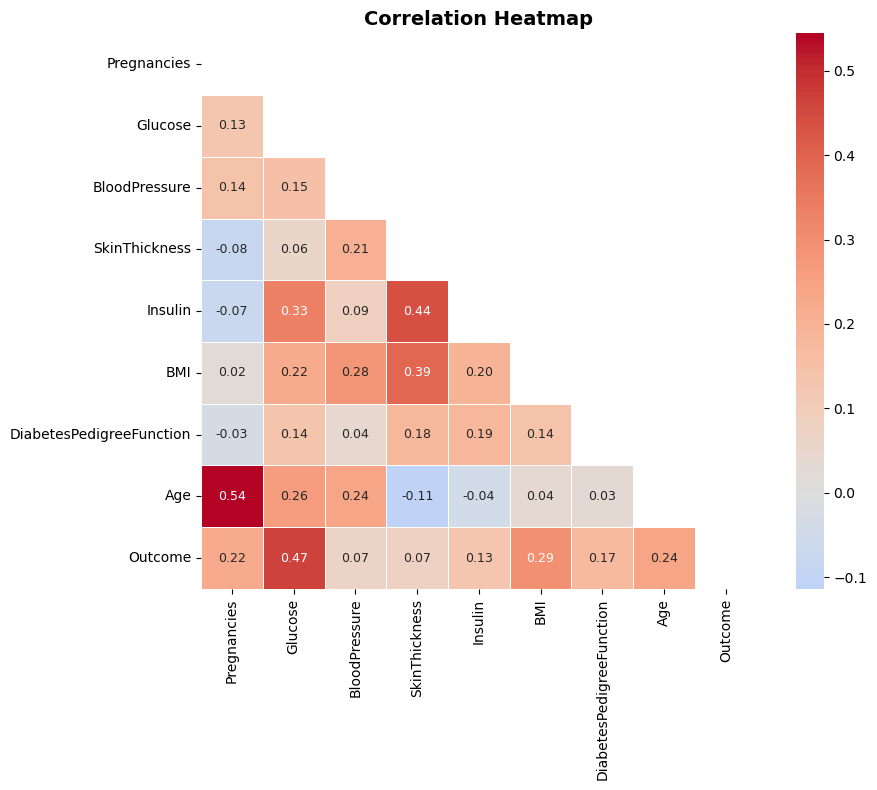


  5. TOP CORRELATIONS WITH OUTCOME
  Glucose                     : +0.467
  BMI                         : +0.293
  Age                         : +0.238
  Pregnancies                 : +0.222
  DiabetesPedigreeFunction    : +0.174
  Insulin                     : +0.131
  SkinThickness               : +0.075
  BloodPressure               : +0.065


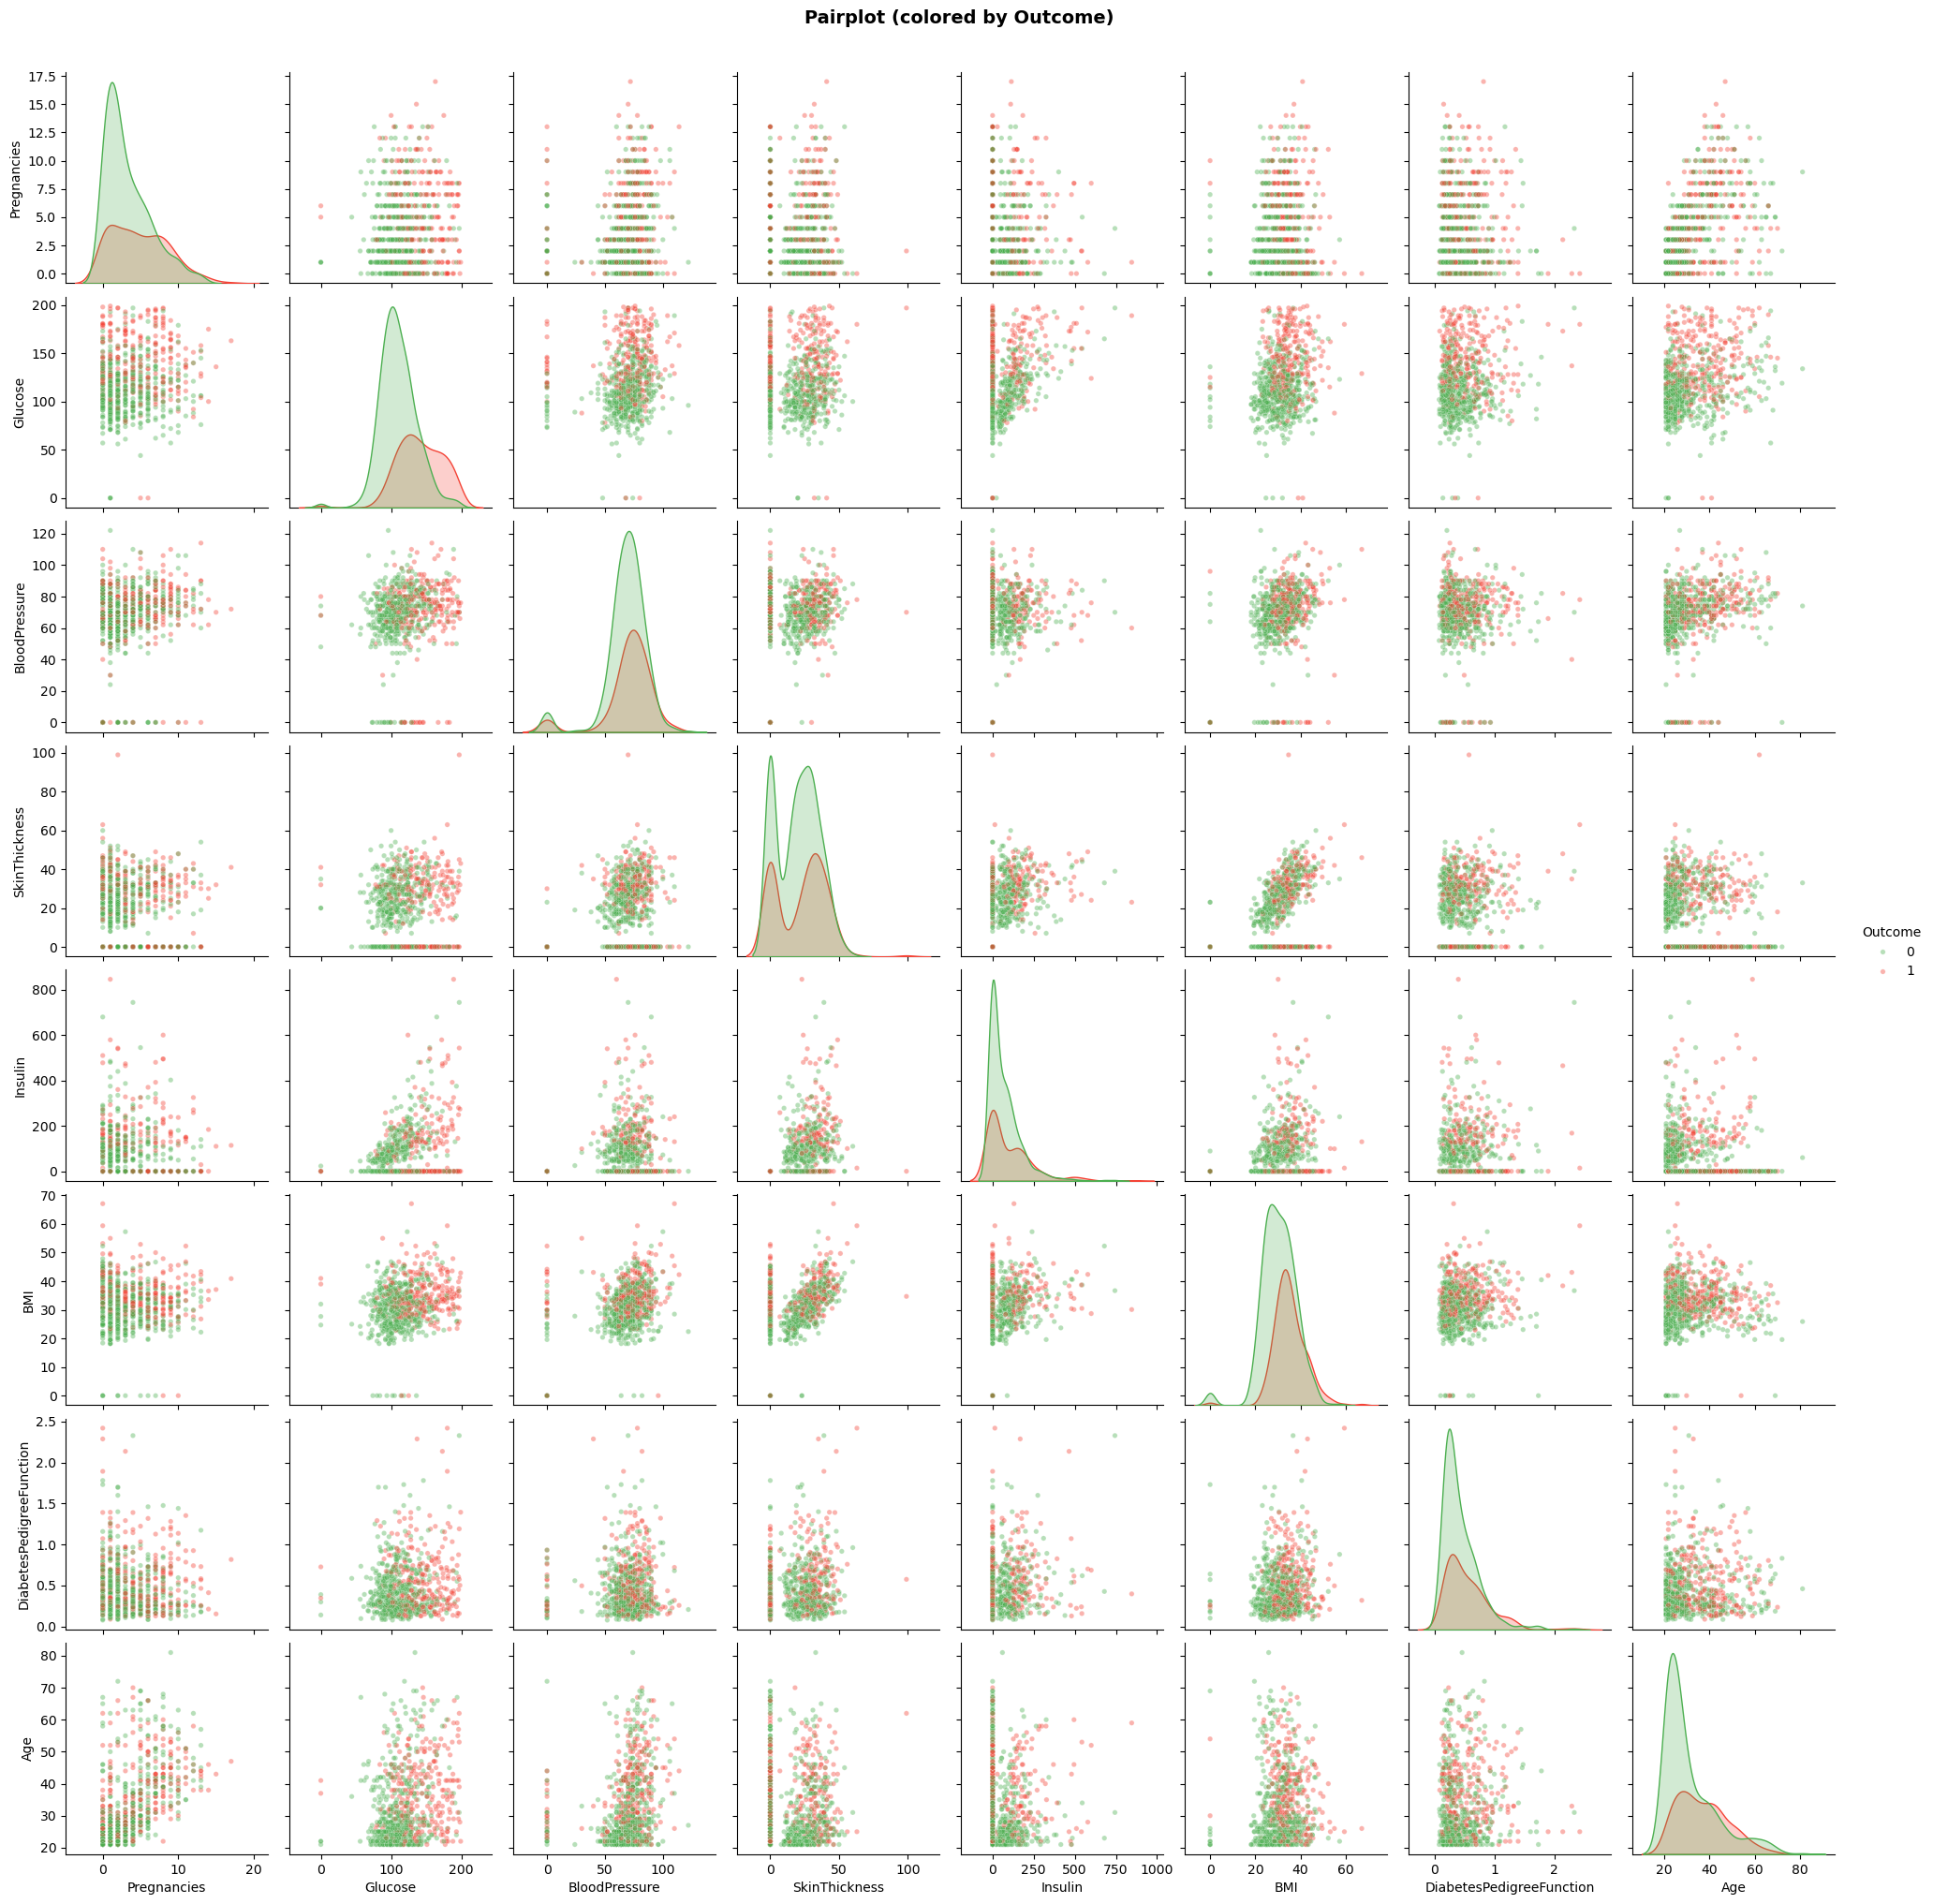

In [13]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 9}, square=True)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_06_correlation_heatmap.png", bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("  5. TOP CORRELATIONS WITH OUTCOME")
print("=" * 60)
corr_outcome = corr['Outcome'].drop('Outcome').sort_values(ascending=False)
for feat, val in corr_outcome.items():
    print(f"  {feat:<28}: {val:>+.3f}")


# Pairplot

pair = sns.pairplot(df, hue='Outcome', palette={0: '#4CAF50', 1: '#F44336'},
                    diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
pair.fig.suptitle("Pairplot (colored by Outcome)", y=1.02, fontsize=14, fontweight='bold')
plt.savefig("plot_07_pairplot.png", bbox_inches='tight')
plt.show()


In [14]:
 # 6. OUTLIER DETECTION — IQR & Z-Score
# ══════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("     OUTLIER DETECTION")
print("=" * 60)
print(f"\n{'Feature':<28} {'IQR Outliers':>14} {'Z-Score Outliers':>18}")
print("-" * 62)
for col in features:
    # IQR method
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    # Z-score method
    z_out = (np.abs(stats.zscore(df[col])) > 3).sum()
    print(f"  {col:<26} {iqr_out:>14} {z_out:>18}")


     OUTLIER DETECTION

Feature                        IQR Outliers   Z-Score Outliers
--------------------------------------------------------------
  Pregnancies                             4                  4
  Glucose                                 5                  5
  BloodPressure                          45                 35
  SkinThickness                           1                  1
  Insulin                                34                 18
  BMI                                    19                 14
  DiabetesPedigreeFunction               29                 11
  Age                                     9                  5


### separate the data

In [15]:
# separate the data and labels 
x = df.drop(columns = 'Outcome', axis = 1)
y = df['Outcome']

## Data Standardization 

In [16]:
scaler = StandardScaler()

In [17]:
x = scaler.fit_transform(x)

### Split the data for train and test

In [18]:
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size = 0.2,stratify=y, random_state = 42)

### Training the model

In [19]:
# training the support vector Machine Classifire
classifier = svm.SVC(kernel = 'linear')

In [20]:
# training the support vector machine Classifire
classifier.fit(x_train,y_train)

SVC(kernel='linear')

## Model Evaluation

In [21]:
y_predict = classifier.predict(x_test)
model_accuracy = accuracy_score(y_predict,y_test)
print(model_accuracy)

0.7207792207792207


## Make a predictive system

In [22]:
input_data = (4,110,92,0,0,37.6,0.191,30)

# changing the input data into numpy array
input_data_nparray = np.asarray(input_data)
# reshape the array as we are predicting for one instance 
input_data_reshape = input_data_nparray.reshape(1,-1)

# standarize the input data 
std_data = scaler.transform(input_data_reshape)
print(std_data)

prediction = classifier.predict(std_data)

if prediction == 1:
    print('The person is diabetic')
else:
    print('The person is not diabetic')

[[ 0.04601433 -0.34096773  1.18359575 -1.28821221 -0.69289057  0.71168975
  -0.84827977 -0.27575966]]
The person is not diabetic


### Outputs:
- Data dosn't contain any null values
- There is no duplicate Rows in the dataset
- The dataset contain 500(65.1%) No Diabetes and 268(34.9%) Diabetes Dataset
- before train the data to a machine learning algorithm we Standarize the data
- here i use `StandardScaler` for the standarization 
- I apply `Support vector Machine (SVM)` Algorithm to predict the output
- here accuracy score of the algorithm is `72%`
  